I0000 00:00:1776782888.924253  711203 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776782888.978093  711203 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776782890.276813  711203 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Starting parallel processing... (Aggregating by physical Sample ID)
Fold 0: Extracted 64 unique SIDs
Fold 1: Extracted 63 unique SIDs
Fold 2: Extracted 63 unique SIDs
Fold 3: Extracted 63 unique SIDs
Fold 4: Extracted 63 unique SIDs

Data processing complete. Calculating final global statistics...

--- Global CV Performance Summary ---
Total physical SIDs evaluated: 316
Global Mean across all SIDs: 13.24%
Global Median across all SIDs: 10.73%
90th Percentile across all SIDs: 24.31%


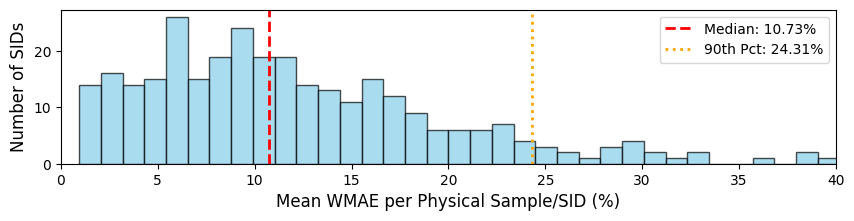

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import helper
import concurrent.futures

# --- 1. FORCE INTERACTIVE PLOTTING ---
%matplotlib inline 
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

# --- 2. SETUP PATHS ---
parent_dir = "final_output_global_from_PSD_dm_500x200"
loss_key = "mse"        
data_npz_path = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/extracted_features/grainet_data_global_from_PSD_500x200.npz"
randCV_indices_path = os.path.join(parent_dir, f"random_5_fold_indices.npy")

# --- 3. LOAD MASTER SAMPLE IDs (SIDs) ---
data = np.load(data_npz_path, allow_pickle=True)
names = data["tile_names"]
SID_RX = re.compile(r"^(?P<sid>\d{1,6})")
sids = np.array([int(SID_RX.match(str(n)).group("sid")) for n in names])

# Load the indices that map CV folds back to the original images
indices_list = np.load(randCV_indices_path, allow_pickle=True)

# --- 4. DEFINE THE PARALLEL WORKER FUNCTION ---
def process_fold(test_fold):
    """Loads and aggregates metrics by physical SID for a single fold."""
    experiment_dir = os.path.join(parent_dir, f"loss_{loss_key}", f"testfold_{test_fold}")
    predictions = np.load(os.path.join(experiment_dir, 'predictions.npy'))
    
    fold_data = helper.wrapper_make_data_split_sample_level(
        experiment_type="randCV",
        data_npz_path=data_npz_path,
        test_fold_index=test_fold,
        num_folds=5,
        output_dm=False 
    )
    y_true_pdf = fold_data['Y_test']
    
    # Get the original dataset indices for this specific fold
    fold_indices = indices_list[test_fold]
    
    # Dictionary to group MAEs by physical Sample ID (SID)
    sid_maes = {}
    
    for i in range(len(y_true_pdf)):
        mae = helper.calculate_curve_mae_percent(y_true_pdf[i], predictions[i])
        
        # Map this specific prediction back to its physical SID
        orig_idx = fold_indices[i]
        sid = sids[orig_idx]
        
        if sid not in sid_maes:
            sid_maes[sid] = []
        sid_maes[sid].append(mae)
        
    # Average the MAEs for each individual SID (Sample)
    fold_sid_means = [np.mean(maes) for sid, maes in sid_maes.items()]
    
    return test_fold, fold_sid_means

# --- 5. EXECUTE IN PARALLEL ---
if __name__ == '__main__':
    all_sid_means = []

    print("Starting parallel processing... (Aggregating by physical Sample ID)")
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=5) as executor:
        results = executor.map(process_fold, range(5))
        
        for test_fold, fold_sid_means in results:
            print(f"Fold {test_fold}: Extracted {len(fold_sid_means)} unique SIDs")
            all_sid_means.extend(fold_sid_means)

    print("\nData processing complete. Calculating final global statistics...")

    # --- 6. CALCULATE FINAL STATISTICS & PLOT ---
    # Calculate the median and mean globally across all pooled SIDs
    global_median = np.median(all_sid_means)
    global_mean = np.mean(all_sid_means)
    global_p90 = np.percentile(all_sid_means, 90)

    print(f"\n--- Global CV Performance Summary ---")
    print(f"Total physical SIDs evaluated: {len(all_sid_means)}")
    print(f"Global Mean across all SIDs: {global_mean:.2f}%")
    print(f"Global Median across all SIDs: {global_median:.2f}%")
    print(f"90th Percentile across all SIDs: {global_p90:.2f}%")
    
    # Plot Histogram of SID-level errors
    plt.figure(figsize=(10, 2))
    plt.hist(all_sid_means, bins=60, color='skyblue', edgecolor='black', alpha=0.7)

    # Plot lines for global metrics
    plt.axvline(global_median, color='red', linestyle='dashed', linewidth=2, label=f'Median: {global_median:.2f}%')
    plt.axvline(global_p90, color='orange', linestyle='dotted', linewidth=2, label=f'90th Pct: {global_p90:.2f}%')

    plt.xlabel('Mean WMAE per Physical Sample/SID (%)', fontsize=12)
    plt.ylabel('Number of SIDs', fontsize=12)
    plt.legend()
    plt.xlim(left=0, right=40)
    plt.show()

Fold 0: Extracted 64 unique SIDs
Fold 1: Extracted 63 unique SIDs
Fold 2: Extracted 63 unique SIDs
Fold 3: Extracted 63 unique SIDs
Fold 4: Extracted 63 unique SIDs

--- Global CV Performance Summary (SID-aggregated) ---
Total SID samples in histogram: 316
Global Mean across SIDs: 13.39%
Global Median across SIDs: 10.34%
90th Percentile across SIDs: 30.33%


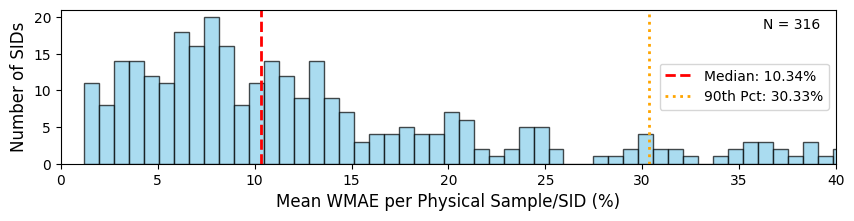

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import helper
import concurrent.futures

%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

parent_dir = "output_global_from_PSD_dm_500x200"
loss_key = "mse"
data_npz_path = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/baseline_other_papers/Lang_grainet/data_global_from_PSD_500x200.npz"
randCV_indices_path = os.path.join(parent_dir, "random_5_fold_indices.npy")

SID_RX = re.compile(r"^(?P<sid>\d{1,6})")

# load indices list (still ok to keep if you need it elsewhere)
indices_list = np.load(randCV_indices_path, allow_pickle=True)

def process_fold(test_fold: int):
    """Compute WMAE per tile (your anchored-CDF method), then mean per physical SID for this fold."""
    experiment_dir = os.path.join(parent_dir, f"loss_{loss_key}", f"testfold_{test_fold}")
    predictions = np.load(os.path.join(experiment_dir, "predictions.npy"))

    fold_data = helper.wrapper_make_data_split_sample_level(
        experiment_type="randCV",
        data_npz_path=data_npz_path,
        test_fold_index=test_fold,
        num_folds=5,
        output_dm=False
    )
    y_true_pdf = fold_data["Y_test"]
    n_test_names = fold_data["N_test"]   # names for the test tiles in this fold

    sid_wmaes = {}  # sid -> list of tile-level WMAEs

    for i in range(len(y_true_pdf)):
        sid = int(SID_RX.match(str(n_test_names[i])).group("sid"))

        # ANCHOR AT COARSE END (80mm = 100%) exactly like your second script
        true_cdf = 1.0 - np.concatenate((np.cumsum(y_true_pdf[i][::-1])[::-1], [0.0]))
        pred_cdf = 1.0 - np.concatenate((np.cumsum(predictions[i][::-1])[::-1], [0.0]))

        abs_diff_cdf = np.abs(pred_cdf - true_cdf)

        wmae_tile = float(np.mean(abs_diff_cdf) * 100.0)

        sid_wmaes.setdefault(sid, []).append(wmae_tile)

    # one WMAE value per SID in this fold
    fold_sid_means = [float(np.mean(v)) for v in sid_wmaes.values()]
    return test_fold, fold_sid_means


if __name__ == "__main__":
    all_sid_means = []

    with concurrent.futures.ProcessPoolExecutor(max_workers=5) as executor:
        for test_fold, fold_sid_means in executor.map(process_fold, range(5)):
            print(f"Fold {test_fold}: Extracted {len(fold_sid_means)} unique SIDs")
            all_sid_means.extend(fold_sid_means)

    all_sid_means = np.asarray(all_sid_means, dtype=float)

    global_median = float(np.median(all_sid_means))
    global_mean   = float(np.mean(all_sid_means))
    global_p90    = float(np.percentile(all_sid_means, 90))
    N = int(all_sid_means.size)

    print("\n--- Global CV Performance Summary (SID-aggregated) ---")
    print(f"Total SID samples in histogram: {N}")
    print(f"Global Mean across SIDs: {global_mean:.2f}%")
    print(f"Global Median across SIDs: {global_median:.2f}%")
    print(f"90th Percentile across SIDs: {global_p90:.2f}%")

    plt.figure(figsize=(10, 2))
    plt.hist(all_sid_means, bins=60, color="skyblue", edgecolor="black", alpha=0.7)
    plt.axvline(global_median, color="red", linestyle="dashed", linewidth=2, label=f"Median: {global_median:.2f}%")
    plt.axvline(global_p90, color="orange", linestyle="dotted", linewidth=2, label=f"90th Pct: {global_p90:.2f}%")
    plt.xlabel("Mean WMAE per Physical Sample/SID (%)", fontsize=12)
    plt.ylabel("Number of SIDs", fontsize=12)
    plt.xlim(left=0, right=40)

    # show N on the figure
    plt.gca().text(
        0.98, 0.95, f"N = {N}",
        transform=plt.gca().transAxes,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    plt.legend()
    plt.show()

--- Global Performance Summary (ABMIL N=252) ---
Excel Reported WMAE Median: 4.06%
Excel Reported WMAE 90th Pct: 10.06%
GRAINet Samples (1 repeat): 316
ABMIL samples (3 repeat): 948


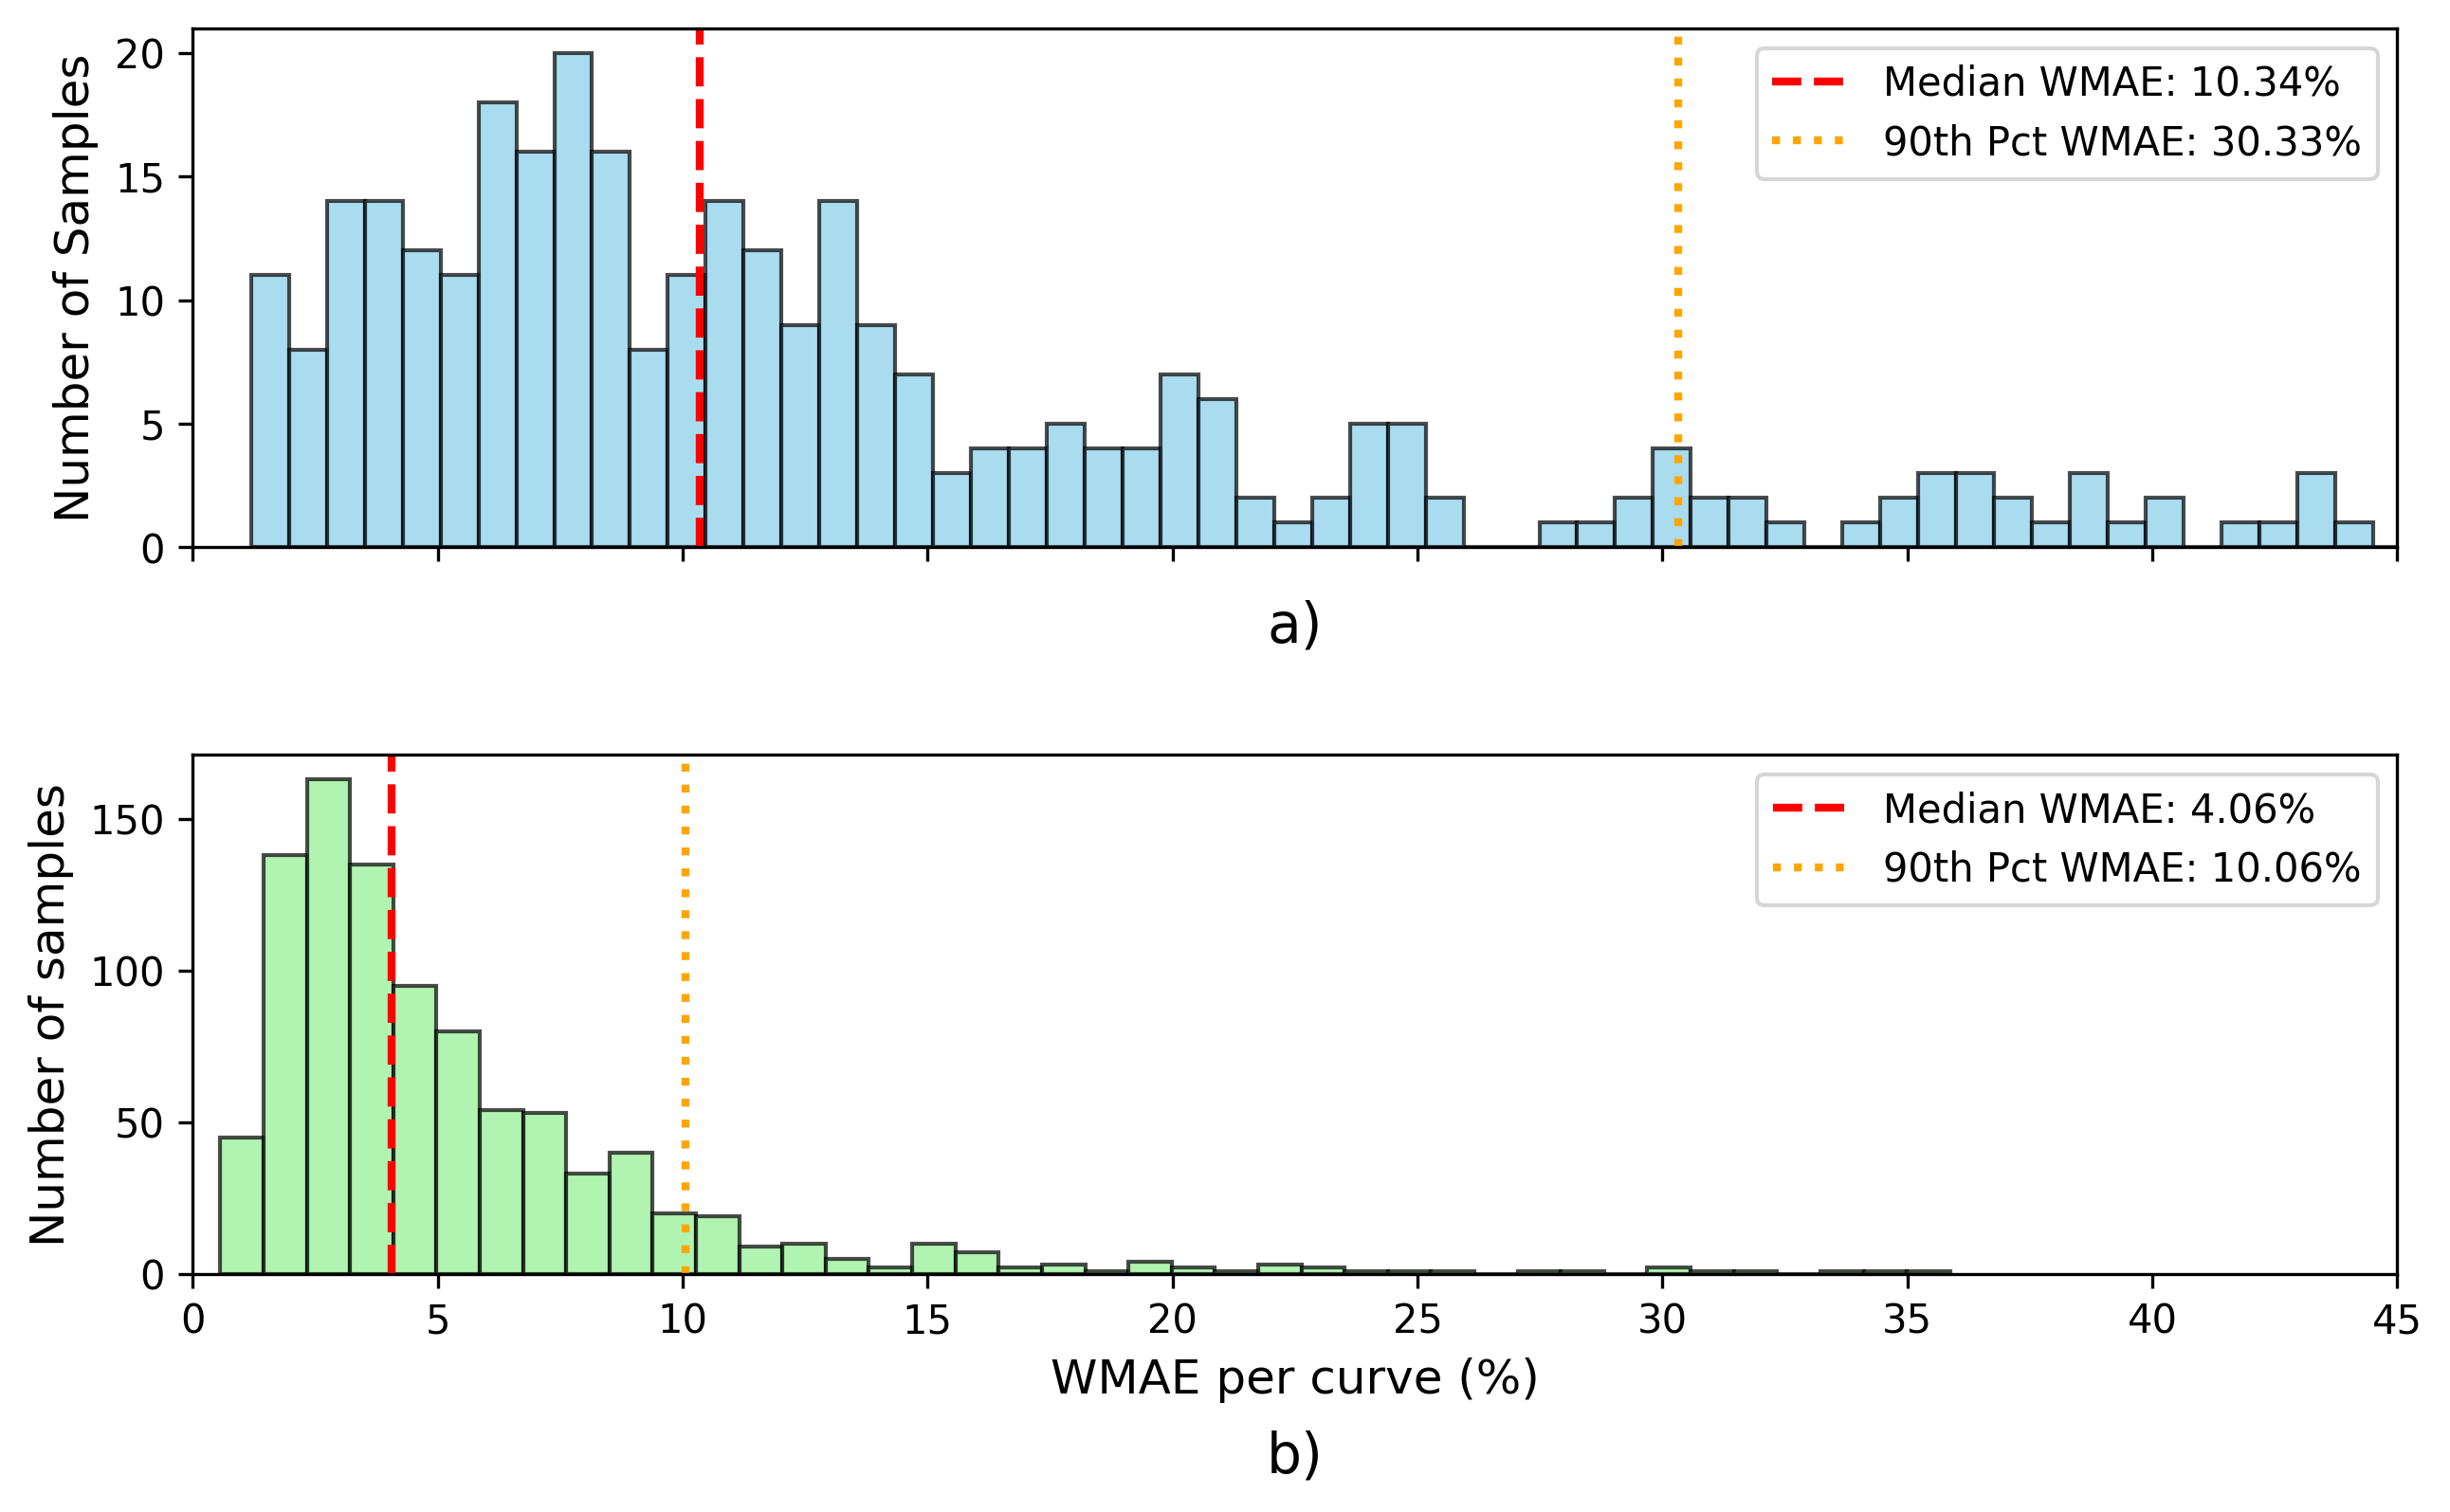

In [13]:
import os
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# SCRIPT 2: ARCHITECTURE ABLATION DATA GATHERING 
# (Assumes cell 1 ran and all_sid_means, global_median, global_p90 are in memory)
# =============================================================================

def infer_bin_spacing(bin_x: np.ndarray) -> np.ndarray:
    bin_x = np.asarray(bin_x, dtype=float)
    if bin_x.ndim != 1: raise ValueError("bin_x must be one-dimensional")
    if bin_x.size == 0: return np.array([], dtype=float)
    if bin_x.size == 1: return np.array([1.0], dtype=float)
    diffs = np.diff(bin_x)
    last = float(diffs[-1]) if diffs.size else 1.0
    return np.concatenate([diffs, [last]])

def ensure_cdf_monotonic(cdf: np.ndarray) -> np.ndarray:
    cdf = np.asarray(cdf, dtype=float)
    cdf = np.clip(cdf, 0.0, 1.0)
    return np.maximum.accumulate(cdf)

def compute_metrics(pred_cdf: np.ndarray, true_cdf: np.ndarray, bin_x: np.ndarray) -> dict:
    pred = ensure_cdf_monotonic(pred_cdf)
    true = ensure_cdf_monotonic(true_cdf)
    spacing = infer_bin_spacing(bin_x)
    diff = np.abs(pred - true)
    weights = spacing / float(np.sum(spacing))
    return {
        "wmae": float(np.sum(diff * weights)), 
        "ks": float(np.max(diff)), 
        "wrmse": float(np.sqrt(np.sum((diff ** 2) * weights)))
    }

def _find_first_index(parts: tuple[str, ...], prefix: str):
    for i, p in enumerate(parts):
        if p.startswith(prefix): return i
    return None

def parse_path_keys(root: Path, preds_path: Path) -> tuple[str, str, str, str]:
    rel = preds_path.relative_to(root)
    parts = rel.parts
    scenario = parts[0]
    idx_seed = _find_first_index(parts, "seed_")
    idx_repeat = _find_first_index(parts, "repeat_")
    cut = idx_seed if idx_seed is not None else (idx_repeat if idx_repeat is not None else len(parts) - 1)
    row_parts = parts[1:cut]
    row_id = "/".join(row_parts) if row_parts else ""
    run_parts = parts[: idx_repeat + 1] if idx_repeat is not None else (parts[: idx_seed + 1] if idx_seed is not None else parts[: len(parts) - 1])
    run_id = "/".join(run_parts)
    return scenario, row_id, run_id, preds_path.stem

def extract_N(val) -> float:
    if val is None: return np.nan
    m = re.search(r"\bN[_-]?(\d+)\b", str(val))
    return float(m.group(1)) if m else np.nan

def pick_n_col(df: pd.DataFrame) -> str:
    candidate_cols = [c for c in df.columns if df[c].astype(str).str.contains(r"\bN[_-]?\d+\b", regex=True, na=False).any()]
    return "row_id" if "row_id" in candidate_cols else candidate_cols[0]

# --- Data Loading Execution ---
SUMMARY_XLSX = Path(r"/home/thomas_plante_stcyr/workspace/torch/2_1_1/model_runs_v2_ABMIL_224px_tiles/sample-count_ablation_2026-02-19_18-22-30/summary_.xlsx")
HIST_N = None  

if not SUMMARY_XLSX.exists():
    fallback = Path("/mnt/data/summary.xlsx")
    if fallback.exists(): SUMMARY_XLSX = fallback
    else: raise FileNotFoundError(f"summary.xlsx not found at: {SUMMARY_XLSX}")

RUN_ROOT = SUMMARY_XLSX.parent
df = pd.read_excel(SUMMARY_XLSX, engine="openpyxl")
df.columns = [str(c).strip() for c in df.columns]

med_col = "WMAE median" if "WMAE median" in df.columns else "wmae_median"
p90_col = "WMAE 90th" if "WMAE 90th" in df.columns else "wmae_ci_high"

n_col = pick_n_col(df)
df["N"] = df[n_col].apply(extract_N)
trend = df.dropna(subset=["N", med_col, p90_col]).copy()

trend_agg = trend.groupby("N", as_index=False).agg(wmae_median=(med_col, "mean"), count=(med_col, "size")).sort_values("N")
use_N = float(HIST_N) if HIST_N is not None else float(trend_agg.loc[trend_agg["wmae_median"].idxmin(), "N"])
sub = trend[np.isclose(trend["N"].astype(float), float(use_N))].copy()

xlsx_median_pct = 100.0 * float(sub[med_col].mean())
xlsx_p90_pct = 100.0 * float(sub[p90_col].mean())

all_pred_files = sorted(RUN_ROOT.rglob("fold_*_preds.json"))
needle = f"N_{int(use_N)}"
pred_files = [p for p in all_pred_files if needle in str(p)]

rows = []
for preds_path in pred_files:
    try: scenario, row_id, run_id, fold = parse_path_keys(RUN_ROOT, preds_path)
    except: continue

    try: payload = json.loads(preds_path.read_text(encoding="utf-8"))
    except: continue

    bin_x = np.asarray(payload.get("bin_x_log10", []), dtype=float)
    pred_list = payload.get("predictions", [])
    if bin_x.size == 0 or not pred_list: continue

    for rec in pred_list:
        sid = rec.get("sid", None)
        if sid is None: continue
        try: sid_int = int(sid)
        except: continue

        pred_cdf = np.asarray(rec.get("pred_cdf", []), dtype=float)
        true_cdf = np.asarray(rec.get("true_cdf", []), dtype=float)
        if pred_cdf.size != true_cdf.size or pred_cdf.size != bin_x.size: continue

        m = compute_metrics(pred_cdf, true_cdf, bin_x)
        rows.append({"scenario": scenario, "row_id": row_id, "run_id": run_id, "fold": fold, "sid": sid_int, "wmae": m["wmae"]})

df_pred = pd.DataFrame(rows)
df_run_sid = df_pred.groupby(["scenario", "row_id", "run_id", "sid"], as_index=False)[["wmae"]].mean()
all_maes_2 = 100.0 * df_run_sid["wmae"].to_numpy(dtype=float)

print(f"--- Global Performance Summary (ABMIL N={int(use_N)}) ---")
print(f"Excel Reported WMAE Median: {xlsx_median_pct:.2f}%")
print(f"Excel Reported WMAE 90th Pct: {xlsx_p90_pct:.2f}%")

# =============================================================================
# COMBINED PLOTTING 
# =============================================================================
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, dpi=300)

# --- Subplot 1 (Top) ---
# References all_sid_means, global_median, and global_p90 from the cell previously run
ax1.hist(all_sid_means, bins=60, color='skyblue', edgecolor='black', alpha=0.7)
print(f"GRAINet Samples (1 repeat): {np.size(all_sid_means)}")
ax1.axvline(global_median, color='red', linestyle='dashed', linewidth=2, label=f'Median WMAE: {global_median:.2f}%')
ax1.axvline(global_p90, color='orange', linestyle='dotted', linewidth=2, label=f'90th Pct WMAE: {global_p90:.2f}%')
ax1.set_ylabel('Number of Samples', fontsize=12)
#ax1.set_title('Lang et al. (2021) Architecture', fontsize=14)
ax1.legend()
ax1.text(0.5, -0.1, "a)", transform=ax1.transAxes, ha="center", va="top", fontsize=14)

# --- Subplot 2 (Bottom) ---
ax2.hist(all_maes_2, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
print(f"ABMIL samples (3 repeat): {np.size(all_maes_2)}")
ax2.axvline(xlsx_median_pct, color='red', linestyle='dashed', linewidth=2, label=f'Median WMAE: {xlsx_median_pct:.2f}%')
ax2.axvline(xlsx_p90_pct, color='orange', linestyle='dotted', linewidth=2, label=f'90th Pct WMAE: {xlsx_p90_pct:.2f}%')
ax2.set_xlabel('WMAE per curve (%)', fontsize=12)
ax2.set_ylabel('Number of samples', fontsize=12)
#ax2.set_title('This paper\'s ABMIL Architecture', fontsize=14)
ax2.legend()
ax2.set_xlim(left=0, right=45)
ax2.text(0.5, -0.30, "b)", transform=ax2.transAxes, ha="center", va="top", fontsize=14)

plt.subplots_adjust(hspace=0.4, bottom=0.15)
plt.show()

In [10]:
import numpy as np
import re
import os
from collections import defaultdict

# --- 1. SETUP PATHS ---
parent_dir = "output_global_from_PSD_dm_500x200"
data_npz_path = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/baseline_other_papers/Lang_grainet/data_global_from_PSD_500x200.npz"
randCV_indices_path = os.path.join(parent_dir, "random_5_fold_indices.npy")

# --- 2. LOAD DATA ---
data = np.load(data_npz_path, allow_pickle=True)
names = data["tile_names"]
indices_list = np.load(randCV_indices_path, allow_pickle=True)

# Extract master SIDs array mapping 1:1 with the dataset images
SID_RX = re.compile(r"^(?P<sid>\d{1,6})")
all_sids = np.array([int(SID_RX.match(str(n)).group("sid")) for n in names])

# --- 3. TRACK SID OCCURRENCES ACROSS FOLDS ---
sid_to_folds = defaultdict(list)
fold_sids_dict = {}

for fold_idx in range(len(indices_list)):
    test_indices = indices_list[fold_idx]
    
    # Extract unique SIDs belonging to the test set of the current fold
    fold_sids = np.unique(all_sids[test_indices])
    fold_sids_dict[fold_idx] = sorted(fold_sids.tolist())
    
    # Track which folds each SID appears in
    for sid in fold_sids:
        sid_to_folds[sid].append(fold_idx)

# --- 4. PROCESS AND DISPLAY SIDs BY FOLD ---
for fold_idx, fold_sids_list in fold_sids_dict.items():
    print(f"\n==================================================")
    print(f" TEST FOLD {fold_idx} ({len(fold_sids_list)} unique SIDs)")
    print(f"==================================================")
    
    # Print in grid format
    per_line = 10
    for i in range(0, len(fold_sids_list), per_line):
        chunk = fold_sids_list[i : i + per_line]
        
        # Add an asterisk to SIDs that appear in multiple folds
        formatted_chunk = []
        for x in chunk:
            if len(sid_to_folds[x]) > 1:
                formatted_chunk.append(f"{x:4}*")
            else:
                formatted_chunk.append(f"{x:4} ")
                
        print(", ".join(formatted_chunk))

# --- 5. CROSS-FOLD OVERLAP REPORT ---
overlapping_sids = {sid: folds for sid, folds in sid_to_folds.items() if len(folds) > 1}

print(f"\n==================================================")
print(f" CROSS-FOLD OVERLAP REPORT")
print(f"==================================================")
if not overlapping_sids:
    print("Clean split: No SIDs were found in the test sets of multiple folds.")
else:
    print(f"Found {len(overlapping_sids)} SIDs that leak across multiple test folds:")
    for sid, folds in sorted(overlapping_sids.items()):
        print(f" - SID {sid:4} appears in Folds: {folds}")
    print("\n* Note: SIDs with overlaps are marked with an asterisk (*) in the grids above.")


 TEST FOLD 0 (64 unique SIDs)
   5 ,    7 ,   10 ,   17 ,   20 ,   24 ,   25 ,   45 ,   48 ,   53 
  54 ,   56 ,   60 ,   62 ,   71 ,   77 ,   92 ,   94 ,  103 ,  105 
 107 ,  116 ,  117 ,  120 ,  130 ,  135 ,  136 ,  137 ,  139 ,  142 
 143 ,  151 ,  156 ,  157 ,  160 ,  166 ,  167 ,  169 ,  174 ,  177 
 181 ,  191 ,  192 ,  213 ,  214 ,  217 ,  241 ,  249 ,  251 ,  261 
 264 ,  268 ,  270 ,  271 ,  278 ,  285 ,  287 ,  289 ,  292 ,  298 
 308 ,  312 ,  314 ,  316 

 TEST FOLD 1 (63 unique SIDs)
  16 ,   18 ,   21 ,   22 ,   27 ,   31 ,   38 ,   41 ,   46 ,   47 
  57 ,   61 ,   63 ,   67 ,   73 ,   78 ,   83 ,   96 ,   98 ,  106 
 112 ,  118 ,  124 ,  128 ,  131 ,  144 ,  148 ,  158 ,  173 ,  176 
 179 ,  186 ,  187 ,  188 ,  193 ,  196 ,  198 ,  200 ,  209 ,  212 
 216 ,  218 ,  224 ,  226 ,  232 ,  233 ,  235 ,  238 ,  254 ,  257 
 258 ,  259 ,  263 ,  269 ,  273 ,  282 ,  291 ,  299 ,  304 ,  305 
 309 ,  310 ,  319 

 TEST FOLD 2 (63 unique SIDs)
   1 ,    3 ,    8 ,   13 ,   14

In [1]:
import numpy as np
import pandas as pd
import re
import os
import concurrent.futures
import helper

# --- 1. CONFIGURATION ---
edges_mm = np.logspace(np.log10(0.05), np.log10(80), 22)
SID_RX = re.compile(r"^(?P<sid>\d{1,6})")

parent_dir = "output_global_from_PSD_dm_500x200"
loss_key = "mse"        
data_npz_path = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/baseline_other_papers/Lang_grainet/data_global_from_PSD_500x200.npz"
psd_path = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/labels/PSD.xlsx"

# Use ALL 22 sieve indices
sieve_indices = np.arange(len(edges_mm))
sieve_labels = [f"AE {edges_mm[i]:.2f}mm" for i in sieve_indices]

def classify_by_size(d50):
    if pd.isna(d50): return "Unknown"
    if d50 > 10:     return "Very Coarse\n(D50 > 10mm)"
    elif d50 > 2:    return "Coarse\n(D50 2-10mm)"
    elif d50 > 0.425:return "Medium\n(D50 0.4-2mm)"
    elif d50 > 0.075:return "Fine\n(D50 0.08-0.4mm)"
    else:            return "Very Fine\n(D50 < 0.08mm)"

# --- 2. LOAD METADATA ---
df_psd = pd.read_excel(psd_path)
if 'D50' in df_psd.columns and df_psd['D50'].dtype == object:
    df_psd['D50'] = df_psd['D50'].astype(str).str.replace(',', '.').astype(float)
d50_map = df_psd.set_index('num_publication')['D50'].to_dict() if 'num_publication' in df_psd.columns else {}

data_raw = np.load(data_npz_path, allow_pickle=True)
all_names = data_raw['tile_names']
all_cdfs = data_raw['histograms']
all_pdfs = np.diff(all_cdfs, axis=1).astype(np.float32)
sids_master = np.array([int(SID_RX.match(str(n)).group("sid")) for n in all_names])

# --- 3. PARALLEL PROCESSING WITH COARSE ANCHORING ---
def process_test_fold(test_fold):
    experiment_dir = os.path.join(parent_dir, f"loss_{loss_key}", f"testfold_{test_fold}")
    predictions = np.load(os.path.join(experiment_dir, 'predictions.npy'))
    fold_data = helper.wrapper_make_data_split_sample_level(
        experiment_type="randCV", 
        data_npz_path=data_npz_path, 
        test_fold_index=test_fold, 
        num_folds=5, 
        output_dm=False
    )
    y_true_pdf, n_test_names = fold_data['Y_test'], fold_data['N_test']
    
    fold_records = []
    for i in range(len(y_true_pdf)):
        sid = int(SID_RX.match(str(n_test_names[i])).group("sid"))
        
        # ANCHOR AT COARSE END (80mm = 100%)
        true_cdf = 1.0 - np.concatenate((np.cumsum(y_true_pdf[i][::-1])[::-1], [0.0]))
        pred_cdf = 1.0 - np.concatenate((np.cumsum(predictions[i][::-1])[::-1], [0.0]))
        
        abs_diff_cdf = np.abs(pred_cdf - true_cdf)
        
        wmae = np.mean(abs_diff_cdf) * 100
        ks = np.max(abs_diff_cdf) * 100
        
        record = {"sid": sid, "WMAE": wmae, "KS": ks}
        
        # Exact bin assignments
        for idx, label in zip(sieve_indices, sieve_labels):
            record[label] = abs_diff_cdf[idx] * 100
            
        # Interpolate 0.08mm in log space
        ae_0_08 = np.interp(np.log10(0.08), np.log10(edges_mm), abs_diff_cdf) * 100
        record["AE 0.08mm"] = ae_0_08
        
        fold_records.append(record)
    return fold_records

if __name__ == '__main__':
    all_test_records = []
    with concurrent.futures.ProcessPoolExecutor(max_workers=5) as executor:
        for records in executor.map(process_test_fold, range(5)):
            all_test_records.extend(records)
            
    # Aggregate by SID
    df_sid = pd.DataFrame(all_test_records).groupby("sid", as_index=False).mean()
    
    def get_group(sid):
        d50 = d50_map.get(sid, np.nan)
        if pd.isna(d50):
            idx = np.where(sids_master == sid)[0][0]
            # Standard fine-anchored CDF for D50 calculation
            cdf = np.maximum.accumulate(np.concatenate(([0.0], np.cumsum(all_pdfs[idx]))))
            d50 = np.interp(0.5, cdf, edges_mm)
        return classify_by_size(d50)

    df_sid['size_group'] = df_sid['sid'].apply(get_group)
    
    # --- 4. AGGREGATION ---
    # Create ordered column labels including the interpolated 0.08mm column
    ordered_labels = sieve_labels.copy()
    ordered_labels.insert(2, "AE 0.08mm")
    
    def summarize(group_df, name):
        res = {
            "Type": name, 
            "Unique SIDs": len(group_df), 
            "WMAE med": group_df["WMAE"].median() if not group_df.empty else np.nan, 
            "KS med": group_df["KS"].median() if not group_df.empty else np.nan
        }
        for label in ordered_labels:
            res[label] = group_df[label].median() if not group_df.empty else np.nan
        return pd.Series(res)

    summary_rows = [summarize(df_sid, "All samples")]
    group_order = [
        "Very Coarse\n(D50 > 10mm)", 
        "Coarse\n(D50 2-10mm)", 
        "Medium\n(D50 0.4-2mm)", 
        "Fine\n(D50 0.08-0.4mm)", 
        "Very Fine\n(D50 < 0.08mm)"
    ]
    
    for grp in group_order:
        summary_rows.append(summarize(df_sid[df_sid["size_group"] == grp], grp))

    df_summary = pd.DataFrame(summary_rows)
    
    # --- 5. FORMATTING ---
    fmt = {col: "{:.2f}%" for col in df_summary.columns if col not in ["Type", "Unique SIDs"]}
    fmt["Unique SIDs"] = "{:.0f}"
    
    display(df_summary.style.format(fmt, na_rep=""))

I0000 00:00:1776701521.560990  665588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776701521.615909  665588 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776701522.821462  665588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


,Type,Unique SIDs,WMAE med,KS med,AE 0.05mm,AE 0.07mm,AE 0.08mm,AE 0.10mm,AE 0.14mm,AE 0.20mm,AE 0.29mm,AE 0.41mm,AE 0.58mm,AE 0.83mm,AE 1.18mm,AE 1.68mm,AE 2.38mm,AE 3.39mm,AE 4.81mm,AE 6.84mm,AE 9.72mm,AE 13.81mm,AE 19.62mm,AE 27.88mm,AE 39.62mm,AE 56.30mm,AE 80.00mm
0,All samples,316,10.34%,22.78%,18.31%,16.23%,15.96%,15.25%,14.61%,14.77%,15.28%,14.91%,13.91%,12.65%,12.56%,11.71%,10.67%,9.77%,9.15%,8.37%,7.24%,6.50%,5.94%,4.57%,2.85%,1.34%,0.00%
1,Very Coarse (D50 > 10mm),11,7.21%,16.88%,5.79%,1.98%,2.27%,2.85%,4.20%,5.08%,5.33%,5.87%,5.69%,5.65%,5.95%,6.51%,7.22%,7.87%,8.07%,8.63%,9.89%,10.29%,9.33%,4.01%,1.31%,0.70%,0.00%
2,Coarse (D50 2-10mm),38,4.83%,11.95%,5.80%,3.54%,3.05%,2.86%,2.78%,3.18%,3.67%,3.88%,4.26%,4.58%,5.18%,5.45%,5.81%,6.51%,6.78%,5.87%,6.45%,4.94%,3.50%,2.31%,1.76%,0.78%,0.00%
3,Medium (D50 0.4-2mm),72,6.70%,15.33%,9.93%,7.53%,6.46%,5.72%,6.29%,7.04%,6.90%,7.09%,7.60%,7.42%,7.26%,6.65%,5.74%,5.78%,5.60%,5.06%,4.14%,3.86%,3.98%,4.06%,2.81%,1.51%,0.00%
4,Fine (D50 0.08-0.4mm),153,12.56%,26.44%,21.24%,19.73%,19.50%,19.43%,20.48%,19.50%,19.40%,19.80%,18.95%,17.53%,15.65%,14.20%,12.78%,11.25%,10.31%,8.50%,7.30%,6.63%,5.41%,4.68%,2.84%,1.23%,0.00%
5,Very Fine (D50 < 0.08mm),42,35.21%,64.62%,62.89%,60.08%,59.22%,57.52%,58.15%,56.07%,51.93%,49.96%,47.42%,44.16%,40.65%,37.60%,34.99%,30.96%,27.09%,22.85%,18.45%,14.14%,9.96%,6.85%,3.86%,1.84%,0.00%


In [2]:
import numpy as np
import pandas as pd
import re
import os
import concurrent.futures
import helper

# --- 1. CONFIGURATION ---
edges_mm = np.logspace(np.log10(0.05), np.log10(80), 22)
SID_RX = re.compile(r"^(?P<sid>\d{1,6})")

parent_dir = "output_global_from_PSD_dm_500x200"
loss_key = "mse"        
data_npz_path = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/baseline_other_papers/Lang_grainet/data_global_from_PSD_500x200.npz"
psd_path = "/home/thomas_plante_stcyr/workspace/torch/2_1_1/scratch/labels/PSD.xlsx"

def classify_by_size(d50):
    if pd.isna(d50): return "Unknown"
    if d50 > 10:     return "Very Coarse\n(D50 > 10mm)"
    elif d50 > 2:    return "Coarse\n(D50 2-10mm)"
    elif d50 > 0.425:return "Medium\n(D50 0.4-2mm)"
    elif d50 > 0.075:return "Fine\n(D50 0.08-0.4mm)"
    else:            return "Very Fine\n(D50 < 0.08mm)"

# --- 2. LOAD METADATA AND MASTER DATA ---
df_psd = pd.read_excel(psd_path)
if 'D50' in df_psd.columns and df_psd['D50'].dtype == object:
    df_psd['D50'] = df_psd['D50'].astype(str).str.replace(',', '.').astype(float)

d50_map = {}
if 'num_publication' in df_psd.columns and 'D50' in df_psd.columns:
    d50_map = df_psd.set_index('num_publication')['D50'].to_dict()

data_raw = np.load(data_npz_path, allow_pickle=True)
all_names = data_raw['tile_names']
all_cdfs = data_raw['histograms']
all_pdfs = np.diff(all_cdfs, axis=1).astype(np.float32)
sids = np.array([int(SID_RX.match(str(n)).group("sid")) for n in all_names])

# --- 3. PARALLEL FOLD PROCESSING (TEST SETS ONLY) ---
# --- 3. PARALLEL FOLD PROCESSING (TEST SETS ONLY) ---
def process_test_fold(test_fold):
    experiment_dir = os.path.join(parent_dir, f"loss_{loss_key}", f"testfold_{test_fold}")
    predictions = np.load(os.path.join(experiment_dir, 'predictions.npy'))
    
    fold_data = helper.wrapper_make_data_split_sample_level(
        experiment_type="randCV",
        data_npz_path=data_npz_path,
        test_fold_index=test_fold,
        num_folds=5,
        output_dm=False 
    )
    y_true_pdf = fold_data['Y_test']
    n_test_names = fold_data['N_test']
    
    fold_records = []
    for i in range(len(y_true_pdf)):
        m = SID_RX.match(str(n_test_names[i]))
        sid = int(m.group("sid")) if m else i
        
        true_cdf = 1.0 - np.concatenate((np.cumsum(y_true_pdf[i][::-1])[::-1], [0.0]))
        pred_cdf = 1.0 - np.concatenate((np.cumsum(predictions[i][::-1])[::-1], [0.0]))
        
        diff = pred_cdf - true_cdf
        abs_diff = np.abs(diff)
        
        wmae = np.mean(abs_diff) * 100

        # Interpolate in log space (same approach as 0.08mm)
        log_edges = np.log10(edges_mm)
        ae_0_08  = np.interp(np.log10(0.08),  log_edges, abs_diff) * 100
        ae_1_25  = np.interp(np.log10(1.25),  log_edges, abs_diff) * 100
        ae_10_00 = np.interp(np.log10(10.0),  log_edges, abs_diff) * 100
        
        fold_records.append({
            "sid": sid,
            "WMAE": wmae,
            "WRMSE": np.sqrt(np.mean(diff ** 2)) * 100,
            "KS": np.max(abs_diff) * 100,
            "Bias": np.mean(diff) * 100,
            "AE 0.08mm": ae_0_08,
            "AE 1.25mm": ae_1_25,
            "AE 10mm": ae_10_00,
        })
    return fold_records

if __name__ == '__main__':
    all_test_records = []
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=5) as executor:
        results = executor.map(process_test_fold, range(5))
        for fold_records in results:
            all_test_records.extend(fold_records)
            
    df_test_all = pd.DataFrame(all_test_records)
    
    # --- 4. AGGREGATE BY SID AND ASSIGN GROUPS ---
    # Average metrics per physical Sample ID
    df_sid = df_test_all.groupby("sid", as_index=False).mean()
    
    def get_d50_and_group(sid):
        d50 = d50_map.get(sid, np.nan)
        if pd.isna(d50):
            idx_matches = np.where(sids == sid)[0]
            if len(idx_matches) > 0:
                idx = idx_matches[0]
                # Standard D50 calculation (anchoring fine is standard for D50)
                cdf = np.concatenate(([0.0], np.cumsum(all_pdfs[idx])))
                cdf_mono = np.maximum.accumulate(cdf)
                d50 = np.interp(0.5, cdf_mono, edges_mm)
        return d50, classify_by_size(d50)

    df_sid[['D50', 'size_group']] = df_sid['sid'].apply(lambda x: pd.Series(get_d50_and_group(x)))
    
    # --- 5. STRATIFICATION AND FORMATTING ---
    def summarize_group(group_df, name):
        return pd.Series({
            "Type": name,
            "Unique Test SIDs": len(group_df),
            "WMAE median": group_df["WMAE"].median() if not group_df.empty else np.nan,
            "WMAE 90th": np.percentile(group_df["WMAE"], 90) if not group_df.empty else np.nan,
            "KS median": group_df["KS"].median() if not group_df.empty else np.nan,
            "KS 90th": np.percentile(group_df["KS"], 90) if not group_df.empty else np.nan,
            "WRMSE median": group_df["WRMSE"].median() if not group_df.empty else np.nan,
            "Bias": group_df["Bias"].mean() if not group_df.empty else np.nan,
            "AE 0.08mm median": group_df["AE 0.08mm"].median() if not group_df.empty else np.nan,
            "AE 1.25mm median": group_df["AE 1.25mm"].median() if not group_df.empty else np.nan,
            "AE 10mm median": group_df["AE 10mm"].median() if not group_df.empty else np.nan,
        })

    summary_rows = [summarize_group(df_sid, "All samples")]

    group_order = [
        "Very Coarse\n(D50 > 10mm)",
        "Coarse\n(D50 2-10mm)",
        "Medium\n(D50 0.4-2mm)",
        "Fine\n(D50 0.08-0.4mm)",
        "Very Fine\n(D50 < 0.08mm)"
    ]

    grouped = df_sid.groupby("size_group")
    for grp in group_order:
        group_df = grouped.get_group(grp) if grp in grouped.groups else pd.DataFrame(columns=df_sid.columns)
        summary_rows.append(summarize_group(group_df, grp))

    df_summary = pd.DataFrame(summary_rows)

    format_dict = {
        "Unique Test SIDs": "{:.0f}",
        "WMAE median": "{:.2f}%", 
        "WMAE 90th": "{:.2f}%", 
        "KS median": "{:.2f}%", 
        "KS 90th": "{:.2f}%", 
        "WRMSE median": "{:.2f}%", 
        "Bias": "{:.2f}%",
        "AE 0.08mm median": "{:.2f}%",
        "AE 1.25mm median": "{:.2f}%",
        "AE 10mm median": "{:.2f}%",
    }

    display(df_summary.style.format(format_dict, na_rep=""))

,Type,Unique Test SIDs,WMAE median,WMAE 90th,KS median,KS 90th,WRMSE median,Bias,AE 0.08mm median,AE 1.25mm median,AE 10mm median
0,All samples,316,10.34%,30.33%,22.78%,58.05%,12.50%,-11.49%,15.96%,12.34%,7.18%
1,Very Coarse (D50 > 10mm),11,7.21%,12.23%,16.88%,28.44%,8.48%,-0.51%,2.27%,6.04%,9.60%
2,Coarse (D50 2-10mm),38,4.83%,9.50%,11.95%,20.59%,5.90%,0.11%,3.05%,5.27%,6.26%
3,Medium (D50 0.4-2mm),72,6.70%,10.17%,15.33%,22.96%,8.14%,-3.28%,6.46%,7.20%,4.13%
4,Fine (D50 0.08-0.4mm),153,12.56%,21.46%,26.44%,42.50%,14.87%,-12.92%,19.50%,15.25%,7.23%
5,Very Fine (D50 < 0.08mm),42,35.21%,43.14%,64.62%,87.60%,40.58%,-33.74%,59.22%,40.11%,18.17%


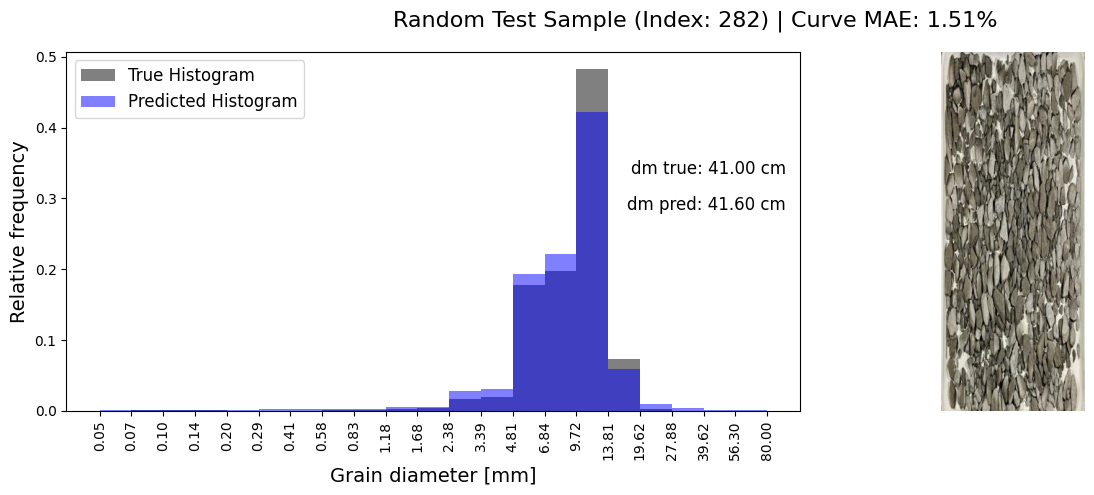

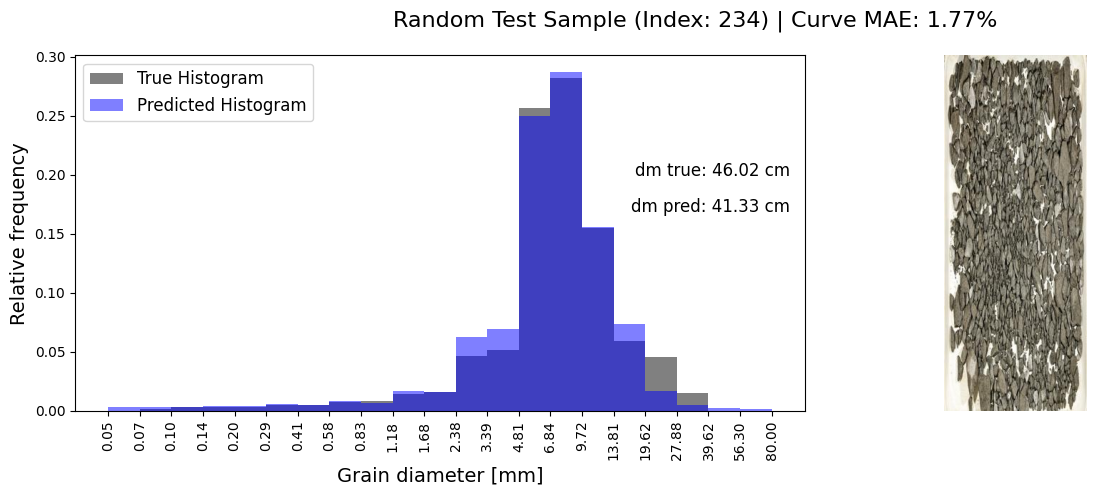

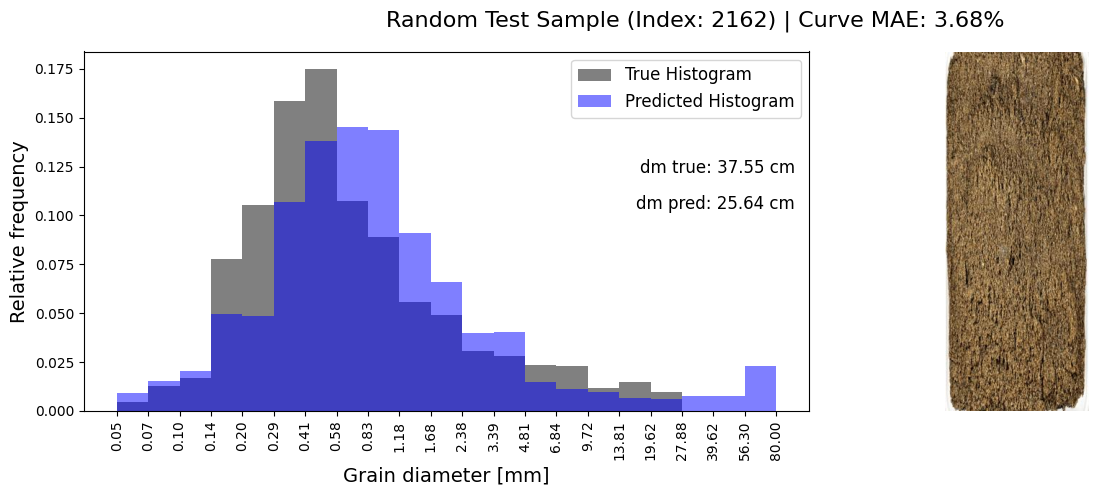

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import helper

# --- 1. FORCE INTERACTIVE PLOTTING ---
%matplotlib inline 
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

# --- 2. SETUP PATHS ---
parent_dir = "output_global_from_PSD_dm_500x200"
loss_key = "mse"        
test_fold = 0           
experiment_dir = os.path.join(parent_dir, f"loss_{loss_key}", f"testfold_{test_fold}")

# --- 3. LOAD DATA (Including Images) ---
predictions = np.load(os.path.join(experiment_dir, 'predictions.npy'))
fold_data = helper.wrapper_make_data_split_sample_level(
    experiment_type="randCV",
    data_npz_path="/home/thomas_plante_stcyr/workspace/torch/2_1_1/baseline_other_papers/Lang_grainet/data_global_from_PSD_500x200.npz",
    test_fold_index=test_fold,
    num_folds=5,
    output_dm=False 
)

y_true_pdf = fold_data['Y_test']
x_test_images = fold_data['X_test'] # Retrieve the raw images

# --- 4. SELECT RANDOM SAMPLES ---
num_samples_to_plot = 3
# Generate 3 unique random indices from the test set
random_indices = random.sample(range(len(y_true_pdf)), num_samples_to_plot)

# Define the log-spaced edges for the x-axis labels
edges_mm = np.logspace(np.log10(0.05), np.log10(80), 22)
group_labels = [f"{x:.2f}" for x in edges_mm]
index_pos = np.arange(len(group_labels) - 1) + 0.5 # 21 bin positions

# --- 5. RENDER RANDOM SAMPLE PLOTS ---
for idx in random_indices:
    img = np.array(x_test_images[idx], dtype=np.uint8)
    hist_true = y_true_pdf[idx]
    hist_pred = predictions[idx]
    
    # Calculate specific metrics for this sample
    mae_curve = helper.calculate_curve_mae_percent(hist_true, hist_pred)
    dm_true = helper.get_dm(hist_true)
    dm_pred = helper.get_dm(hist_pred)
    
    # Create Figure
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    fig.suptitle(f'Random Test Sample (Index: {idx}) | Curve MAE: {mae_curve:.2f}%', fontsize=16)

    # Plot Bar Chart
    ax1.bar(index_pos, hist_true, width=1.0, color='gray', label='True Histogram')
    ax1.bar(index_pos, hist_pred, width=1.0, color='blue', alpha=0.5, label='Predicted Histogram')
    ax1.legend(fontsize=12)

    ax1.set_xlabel('Grain diameter [mm]', fontsize=14)
    ax1.set_ylabel('Relative frequency', fontsize=14)
    ax1.set_xticks(np.arange(len(group_labels)))
    ax1.set_xticklabels(group_labels, rotation=90)
    
    # Text Annotations
    ax1.text(0.98, 0.70, 'dm true: %.2f cm' % (dm_true), ha='right', va='top', transform=ax1.transAxes, fontsize=12)
    ax1.text(0.98, 0.60, 'dm pred: %.2f cm' % (dm_pred), ha='right', va='top', transform=ax1.transAxes, fontsize=12)

    # Plot Image
    ax2.imshow(img)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

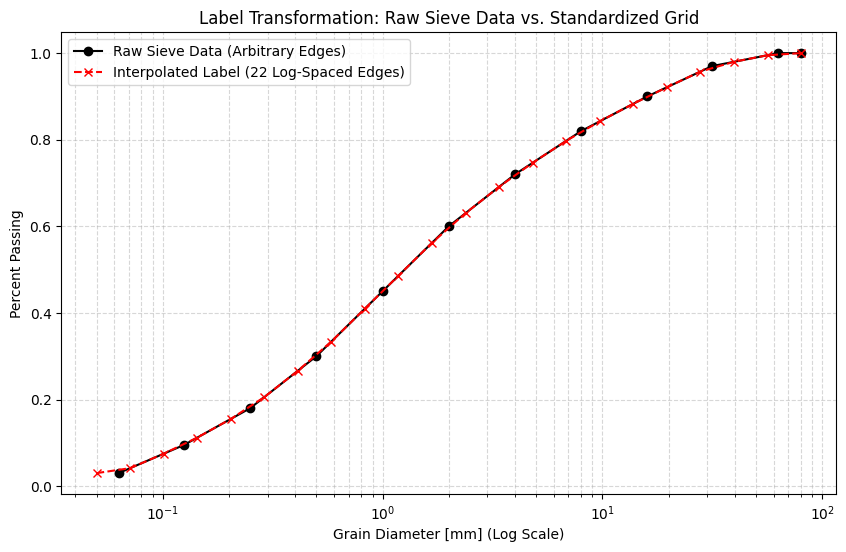

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the target grid (from your script)
LANG_EDGES_MM = np.logspace(np.log10(0.05), np.log10(80), 22)

# 2. Define the transformation function (from your script)
def build_lang_cdf_from_row(row: pd.Series) -> np.ndarray:
    sieve_sizes_mm = []
    percents = []

    for col, val in row.items():
        if isinstance(col, str) and col.startswith("%_") and col.endswith("mm"):
            size_str = col[2:-2]
            try:
                size_mm = float(size_str)
            except ValueError:
                continue

            if pd.isna(val):
                continue

            sieve_sizes_mm.append(size_mm)
            percents.append(float(val))

    if not sieve_sizes_mm:
        raise ValueError(f"No %_Xmm columns found in row, row index={row.name}")

    sieve_sizes_mm = np.array(sieve_sizes_mm, dtype=float)
    percents = np.array(percents, dtype=float)

    order = np.argsort(sieve_sizes_mm)
    sieve_sizes_mm = sieve_sizes_mm[order]
    percents = percents[order]

    cdf_values = percents / 100.0

    nonzero_mask = sieve_sizes_mm > 0
    s_mm_log_safe = sieve_sizes_mm[nonzero_mask]
    c_val_log_safe = cdf_values[nonzero_mask]

    if len(s_mm_log_safe) == 0:
        raise ValueError("No non-zero sieve sizes available for log interpolation.")

    cdf_interp = np.interp(
        np.log(LANG_EDGES_MM),
        np.log(s_mm_log_safe),
        c_val_log_safe,
        left=c_val_log_safe[0],
        right=c_val_log_safe[-1]
    )

    cdf_interp = np.maximum.accumulate(cdf_interp)
    cdf_interp = np.clip(cdf_interp, 0.0, 1.0)
    return cdf_interp


# 3. Create a mock row simulating PSD.xlsx data
mock_data = {
    "num_publication": 999999,
    "%_0.063mm": 3.0,
    "%_0.125mm": 9.5,
    "%_0.25mm": 18.0,
    "%_0.5mm": 30.0,
    "%_1mm": 45.0,
    "%_2mm": 60.0,
    "%_4mm": 72.0,
    "%_8mm": 82.0,
    "%_16mm": 90.0,
    "%_31.5mm": 97.0,
    "%_63mm": 100.0,
    "%_80mm": 100.0
}
mock_row = pd.Series(mock_data)

# 4. Extract raw data for plotting comparison
raw_sizes = []
raw_percents = []
for col, val in mock_row.items():
    if isinstance(col, str) and col.startswith("%_") and col.endswith("mm"):
        raw_sizes.append(float(col[2:-2]))
        raw_percents.append(float(val) / 100.0)
        
order = np.argsort(raw_sizes)
raw_sizes = np.array(raw_sizes)[order]
raw_percents = np.array(raw_percents)[order]

# 5. Apply the transformation
transformed_cdf = build_lang_cdf_from_row(mock_row)

# 6. Plot the comparison
plt.figure(figsize=(10, 6))

# Plot raw data
plt.plot(raw_sizes, raw_percents, marker='o', linestyle='-', color='black', label='Raw Sieve Data (Arbitrary Edges)')

# Plot transformed data
plt.plot(LANG_EDGES_MM, transformed_cdf, marker='x', linestyle='--', color='red', label='Interpolated Label (22 Log-Spaced Edges)')

plt.xscale('log')
plt.xlabel('Grain Diameter [mm] (Log Scale)')
plt.ylabel('Percent Passing')
plt.title('Label Transformation: Raw Sieve Data vs. Standardized Grid')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()